# Single-nucleus RNA-seq beetle (*Nicrophorus vespilloides*): differential expression and shifts in cell proportions

Here, we perform differential cell proportion shifts testing and gene expression analysis between *N. vespilloides* larvae with parental care ('fc') and those without ('nc'). Our goal is to identify how the loss of parental care alters tissue composition and transcriptional profiles during larval development.

# Table of Contents
1. [Differences in cell proportions](#part1)
2. [Single-cell DE tests](#part2)
3. [Gene expression heatmaps](#part3)

In [2]:
library(Seurat)
library(tidyverse)
library(dittoSeq)

In [3]:
packageVersion("Seurat")

[1] ‘5.4.0’

Load the final seurat object

In [4]:
objnames <- LoadSeuratRds("Nicves_beetle_final_seurat_obj.rds")

## 1. Differences in cell abundance

To reproduce the figure panel presented in the manuscript, we generate and combine three subplots:

* **a. Barplot** showing cell proportions across samples for each cluster.
* **b. Barplot** displaying $\log_2$ odds ratios from Fisher's exact tests to illustrate effect size (direction and strength of change).
* **c. Heatmap** illustrating adjusted p-values computed via **[Scanpro](https://www.nature.com/articles/s41598-024-66381-7)** cell proportion tests.

In [5]:
library(dplyr)
library(ggplot2)
library(patchwork)

### a. Cell proportions

Directly extract cell proportion from the Seurat object

In [6]:
nb.cells <- dittoBarPlot(objnames, var='orig.ident', group.by = "seurat_clusters_labels", scale='percent', 
             color.panel= c("#e72b2eff", "#468dc8ee"), retain.factor.levels=TRUE, data.out =T)

levels_clus <- levels(nb.cells$p$data$grouping)

head(nb.cells$data[,c('label','grouping','count', 'percent')])

,label,grouping,count,percent
,<fct>,<fct>,<int>,<dbl>
1,fc_larvae,muscle.rbm24_0,1250,0.3262856
2,nc_larvae,muscle.rbm24_0,2581,0.6737144
3,fc_larvae,muscle.tup_19,54,0.3970588
4,nc_larvae,muscle.tup_19,82,0.6029412
5,fc_larvae,gland.corpora-allata_22,9,0.1836735
6,nc_larvae,gland.corpora-allata_22,40,0.8163265


In [7]:
table(objnames$orig.ident)


fc_larvae nc_larvae 
     5459     10742 

In [8]:
expected = 10742/(10742+5459)

Coordinate system already present.
ℹ Adding new coordinate system, which will replace the existing one.
Warning message:
“Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
ℹ Please use `linewidth` instead.”


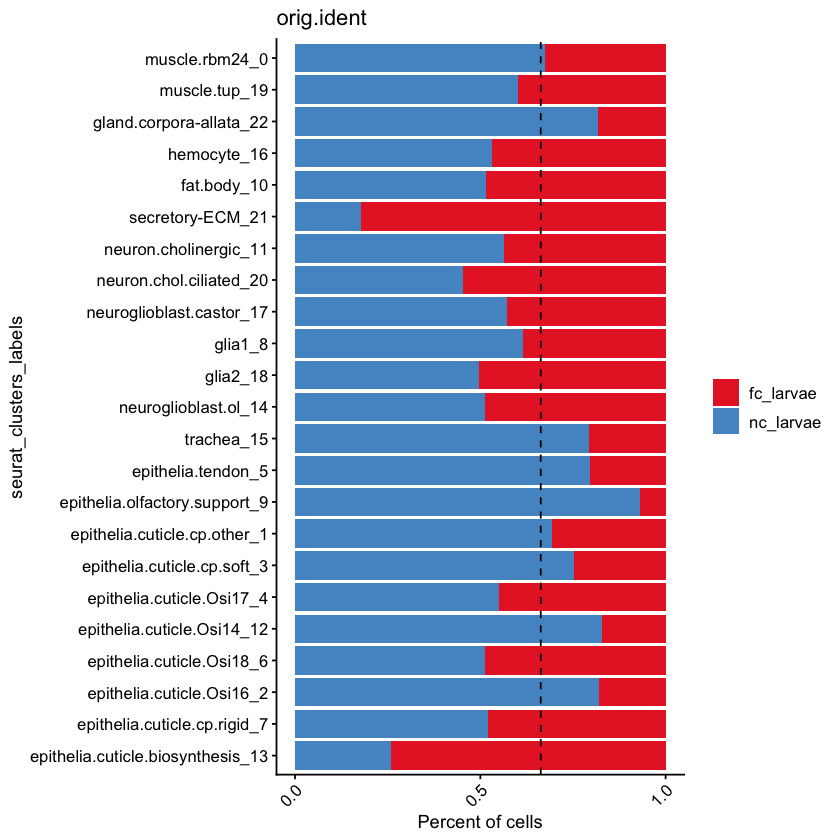

In [9]:
p1 <- nb.cells$p + coord_flip() + scale_x_discrete(limits = rev) +  theme(
    axis.text.x = element_text(size = 10), # Gene labels
    axis.text.y = element_text(size = 10), # Cluster labels
    legend.text = element_text(size = 10),  # Legend font
  ) +   geom_hline(yintercept = expected, color = "black", linetype = "dashed", size = 0.5)
# p1

### b. Fisher's odds ratios

In [11]:
counts <- table(Idents(objnames), objnames$orig.ident)

# Iterate through each cell type to run a 2x2 Fisher Test
results <- lapply(rownames(counts), function(cell_type) {
  
  this_type <- counts[cell_type, ]
  other_types <- colSums(counts) - this_type
  contingency_matrix <- rbind(this_type, other_types)
  test <- fisher.test(contingency_matrix)
  
  # return data frame row
  data.frame(
    CellType = cell_type,
    P_Value = test$p.value,
    Log2OR = log2(test$estimate)
  )
})

fisher_odds <- do.call(rbind, results)
fisher_odds$Adj_P_Value <- p.adjust(fisher_odds$P_Value, method = "bonferroni")

fisher_odds <- fisher_odds %>%
  mutate(color_cat = case_when(
    Log2OR > 1.5  ~ ">1.5",
    Log2OR < -1.5 ~ "<-1.5",
    TRUE        ~ "Low" # abs(Log2FC) <= 1
  ))

head(fisher_odds[,c("CellType", "Log2OR", "color_cat")])

,CellType,Log2OR,color_cat
,<chr>,<dbl>,<chr>
odds ratio,muscle.rbm24_0,-0.09074711,Low
odds ratio1,muscle.tup_19,0.37710622,Low
odds ratio2,gland.corpora-allata_22,-1.17838834,Low
odds ratio3,hemocyte_16,0.80331732,Low
odds ratio4,fat.body_10,0.91452812,Low
odds ratio5,secretory-ECM_21,3.18575126,>1.5


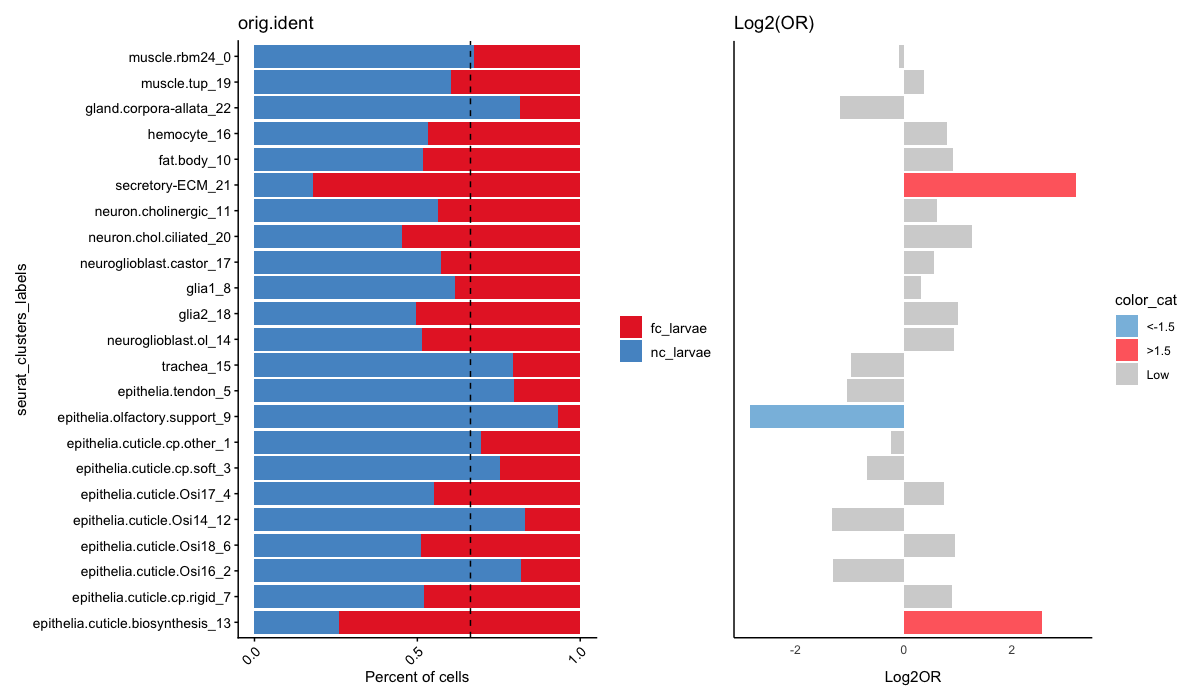

In [13]:
options(repr.plot.width = 12, repr.plot.height = 7, repr.plot.res = 100)

levels_clus <- levels(nb.cells$p$data$grouping) 
fisher_odds$CellType <- factor(fisher_odds$CellType, 
                                     levels = levels_clus)

p_log2fc <- ggplot(fisher_odds, aes(x = CellType, y = Log2OR, fill = color_cat)) +
  geom_col() +
  coord_flip() + scale_fill_manual(values = c(">1.5" = "#ff6b6d",   
                                             "<-1.5" = "#89bde0",
                                               "Low" = "#D3D3D3")) +
scale_x_discrete(limits = rev) + 
  theme_minimal() +
  theme(
    axis.text.y = element_blank(),
    axis.title.y = element_blank(),
      panel.grid = element_blank(),
      axis.line.x = element_line(colour = "black"),
      axis.line.y = element_line(colour = "black")
  ) +
  labs(title = "Log2(OR)")

# p1 + p_log2fc


### c. Adjusted p-values from Scanpro

To rigorously evaluate whether the observed shifts in cell proportions are statistically significant, we use **[Scanpro](https://www.nature.com/articles/s41598-024-66381-7)**. Since our experimental design consists of non-replicated data, we used bootstrapping and applied the recommended `transform='arcsin'` argument (see `scanpro/run_scanpro.py`).

Load Scanpro output (generated with `scanpro/run_scanpro.py`)

In [16]:
scanpro = read.table('scanpro/Ni2_scanpro_arcsin_default-5rep-100sim.tsv', sep='\t', header=T)

scanpro <- scanpro %>%
  mutate(
    neg_log10_p = -log10(adjusted_p_values),
    label_ns = ifelse(adjusted_p_values > 0.05, "ns", ""), # ns if p > 0.05
    dummy_x = "adj.p-val" 
  )

scanpro <- scanpro %>%
  mutate(clusters = factor(clusters, levels = levels_clus)) %>%
  arrange(clusters)

head(scanpro)

,clusters,baseline_props,mean_props_nc_larvae,mean_props_fc_larvae,adjusted_p_values,neg_log10_p,label_ns,dummy_x
,<fct>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>
1,muscle.rbm24_0,0.236466885,0.2396798368,0.228686631,0.5042148,0.2973844,ns,adj.p-val
2,muscle.tup_19,0.008394544,0.0066424375,0.008935372,0.6267930,0.2028758,ns,adj.p-val
3,gland.corpora-allata_22,0.003024505,0.0031056862,0.001023111,0.6471816,0.1889738,ns,adj.p-val
4,hemocyte_16,0.017961854,0.0127099514,0.023346062,0.3905144,0.4083630,ns,adj.p-val
5,fat.body_10,0.030862292,0.0222240065,0.042972223,0.1964242,0.7068049,ns,adj.p-val
6,secretory-ECM_21,0.004135547,0.0007225169,0.009056356,0.1078715,0.9670931,ns,adj.p-val


In [17]:
p_pval <- ggplot(scanpro, aes(x = dummy_x, y = clusters, fill = neg_log10_p)) +
  geom_tile(color = "white") + # Case de la heatmap
  geom_text(aes(label = label_ns), size = 3) + # Texte "ns"
  scale_y_discrete(limits = rev) + # Synchroniser l'ordre
  # Dégradé de couleur (ex: du blanc au violet foncé)
  scale_fill_gradient(low = "white", high = "#6a3d9a", name = "-log10(adj.pval)") +
  theme_minimal() +
  theme(
    panel.grid = element_blank(),
    axis.text.y = element_blank(),
    axis.title = element_blank(),
    axis.text.x = element_text(angle = 45, hjust = 1),
    legend.position = "right"
  )+labs(title = "adj.pvalue")

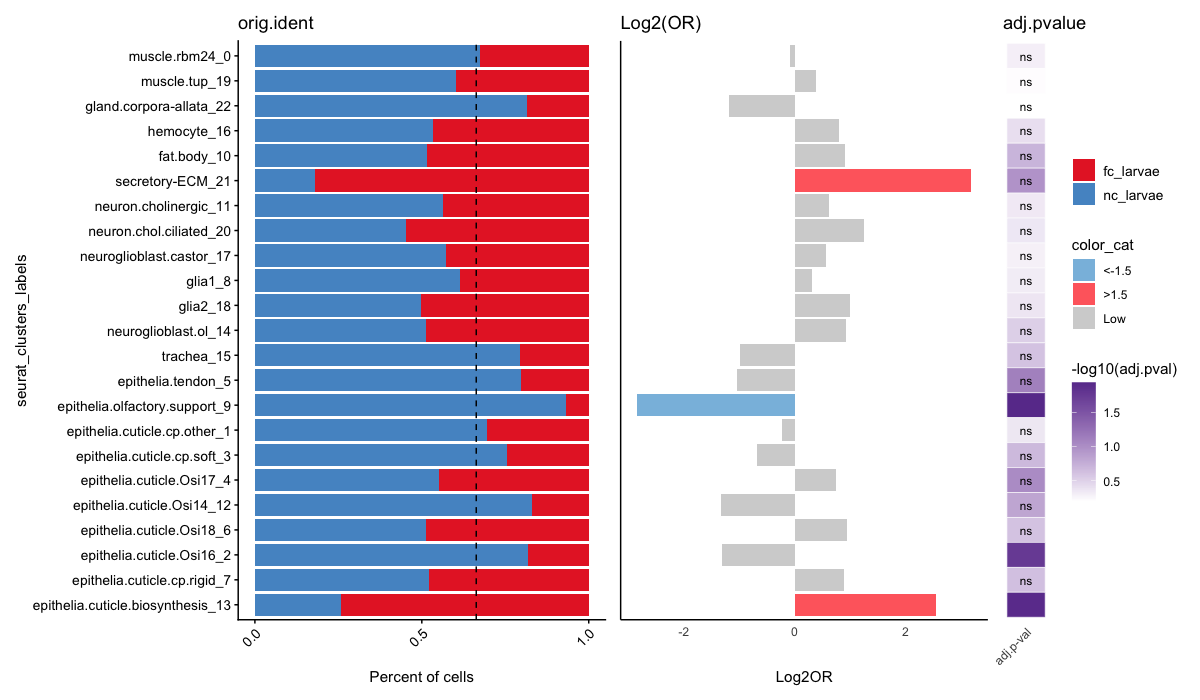

In [18]:
options(repr.plot.width = 12, repr.plot.height = 7, repr.plot.res = 100)

p1 + p_log2fc + p_pval + 
  plot_layout(
    widths = c(8, 8, 1), 
    guides = "collect" 
  )

## 2. Single-cell DE tests: Care vs NoCare

To identify transcriptional differences driven by the presence or absence of parental care, we perform **differential gene expression** (DE) analysis for each cell cluster. We compare larvae with parental care ('fc') against those without ('nc') using Seurat's implementation of the Wilcoxon rank-sum test.

Define global variables for single-cell order and colors

In [20]:
maplabel <- c("0" = "muscle.rbm24_0", "1" = "epithelia.cuticle.cp.other_1", "2" = "epithelia.cuticle.Osi16_2", "3" = 'epithelia.cuticle.cp.soft_3',
                         "4" = "epithelia.cuticle.Osi17_4",
  "5" = "epithelia.tendon_5", "6"="epithelia.cuticle.Osi18_6", "7"="epithelia.cuticle.cp.rigid_7", "8"="glia1_8",
  "9" = "epithelia.olfactory.support_9", "10" = "fat.body_10", "11"="neuron.cholinergic_11", "12"="epithelia.cuticle.Osi14_12",
  "13"="epithelia.cuticle.biosynthesis_13", "14"="neuroglioblast.ol_14","15"="trachea_15", "16"="hemocyte_16",
  "17"="neuroglioblast.castor_17", "18"="glia2_18", "19"="muscle.tup_19",
  "20"="neuron.chol.ciliated_20", "21"="secretory-ECM_21", "22"="gland.corpora-allata_22")
  
my_order <- c("muscle.rbm24_0", "muscle.tup_19", "gland.corpora-allata_22","hemocyte_16","fat.body_10", "secretory-ECM_21","neuron.cholinergic_11", "neuron.chol.ciliated_20",
              "neuroglioblast.castor_17", "glia1_8", "glia2_18", "neuroglioblast.ol_14",
              "trachea_15","epithelia.tendon_5", "epithelia.olfactory.support_9", "epithelia.cuticle.cp.other_1", 
              'epithelia.cuticle.cp.soft_3',"epithelia.cuticle.Osi17_4",
               "epithelia.cuticle.Osi14_12", "epithelia.cuticle.Osi18_6","epithelia.cuticle.Osi16_2",
              "epithelia.cuticle.cp.rigid_7", "epithelia.cuticle.biosynthesis_13")

my_colors_spec <- c("epithelia.cuticle.cp.other_1" = 'goldenrod2', "epithelia.cuticle.Osi14_12" = '#fdff9dff',
               "muscle.rbm24_0" = '#ffc0cbcc',"muscle.tup_19"='#ee6aa7cc',
               "epithelia.cuticle.Osi16_2" = "#fff8dccc", "epithelia.cuticle.Osi17_4"="#ffdd94",
               "epithelia.cuticle.cp.soft_3"='#ffe6b0cc', "epithelia.cuticle.cp.rigid_7"='#c57f00cc',
               "epithelia.cuticle.biosynthesis_13"='#ffc078', "gland.corpora-allata_22"='purple',
               "secretory-ECM_21"='#2cae50be', "epithelia.tendon_5"='#ff7f50cc',
               "neuroglioblast.ol_14" = '#1ed9f8f4', "neuroglioblast.castor_17"='#15affeff',
               "glia1_8"='lightblue2', "glia2_18"='#63b8ffcc',
               "neuron.cholinergic_11"='#000080cc', "neuron.chol.ciliated_20"="#4682b4cc","fat.body_10"='#7f7f7fff',
               "epithelia.olfactory.support_9"='darkorange2', "hemocyte_16"='#8e6100cc', "epithelia.cuticle.Osi18_6"='bisque3',
               "trachea_15"='#ee0000cc')

Prepare object

In [21]:
objnames$celltype.sample <- paste(objnames$seurat_clusters, objnames$orig.ident, sep = "-")

objnames <- PrepSCTFindMarkers(objnames, assay = "SCT")

Found 2 SCT models. Recorrecting SCT counts using minimum median counts: 634



Perform DE tests

In [ ]:
# set idents to do DE cluster by cluster
objnames$celltype.sample <- paste(objnames$seurat_clusters, objnames$orig.ident, sep = "-")
Idents(objnames) <- "celltype.sample"

# DE all clusters 

de.list <- list()
for (i in 0:22) {
    clusde <- FindMarkers(
    objnames,
    ident.1 = paste(i, "fc_larvae", sep = "-"),
    ident.2 = paste(i, "nc_larvae", sep = "-"),
    verbose = T,
    assay = "SCT",
    test.use = 'wilcox'
  )
  
  clusde$cluster <- i
  clusde$gene <- rownames(clusde)
  de.list[[paste0("cluster_", i)]] <- clusde
}

# Combine into one table
all.de <- do.call(rbind, de.list)
outfile <- paste('all_DE_sctOK_wilcox.tsv', sep='')
write.table(all.de, outfile, quote=F, sep='\t', row.names = T)

In [23]:
head(all.de)

,p_val,avg_log2FC,pct.1,pct.2,p_val_adj,cluster,gene
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<chr>
cluster_0.NVE07425,0,-4.333589,0.086,0.841,0,0,NVE07425
cluster_0.RS3A,0,-2.712123,0.377,0.959,0,0,RS3A
cluster_0.ACT-2,0,-2.684568,0.426,0.979,0,0,ACT-2
cluster_0.PATH-3,0,-2.500112,0.383,0.917,0,0,PATH-3
cluster_0.RS8,0,-2.078144,0.474,0.944,0,0,RS8
cluster_0.ACT-1,0,-2.706297,0.684,1.000,0,0,ACT-1


In [24]:
# Reset the idents to cluster names
Idents(objnames) <- objnames@meta.data$seurat_clusters_labels
Idents(objnames) <- factor(objnames@meta.data$seurat_clusters_labels, sort(levels(objnames@meta.data$seurat_clusters_labels)))
levels(objnames) <- my_order

**HSP83** is amon the genes signficantly DE, UP in Care

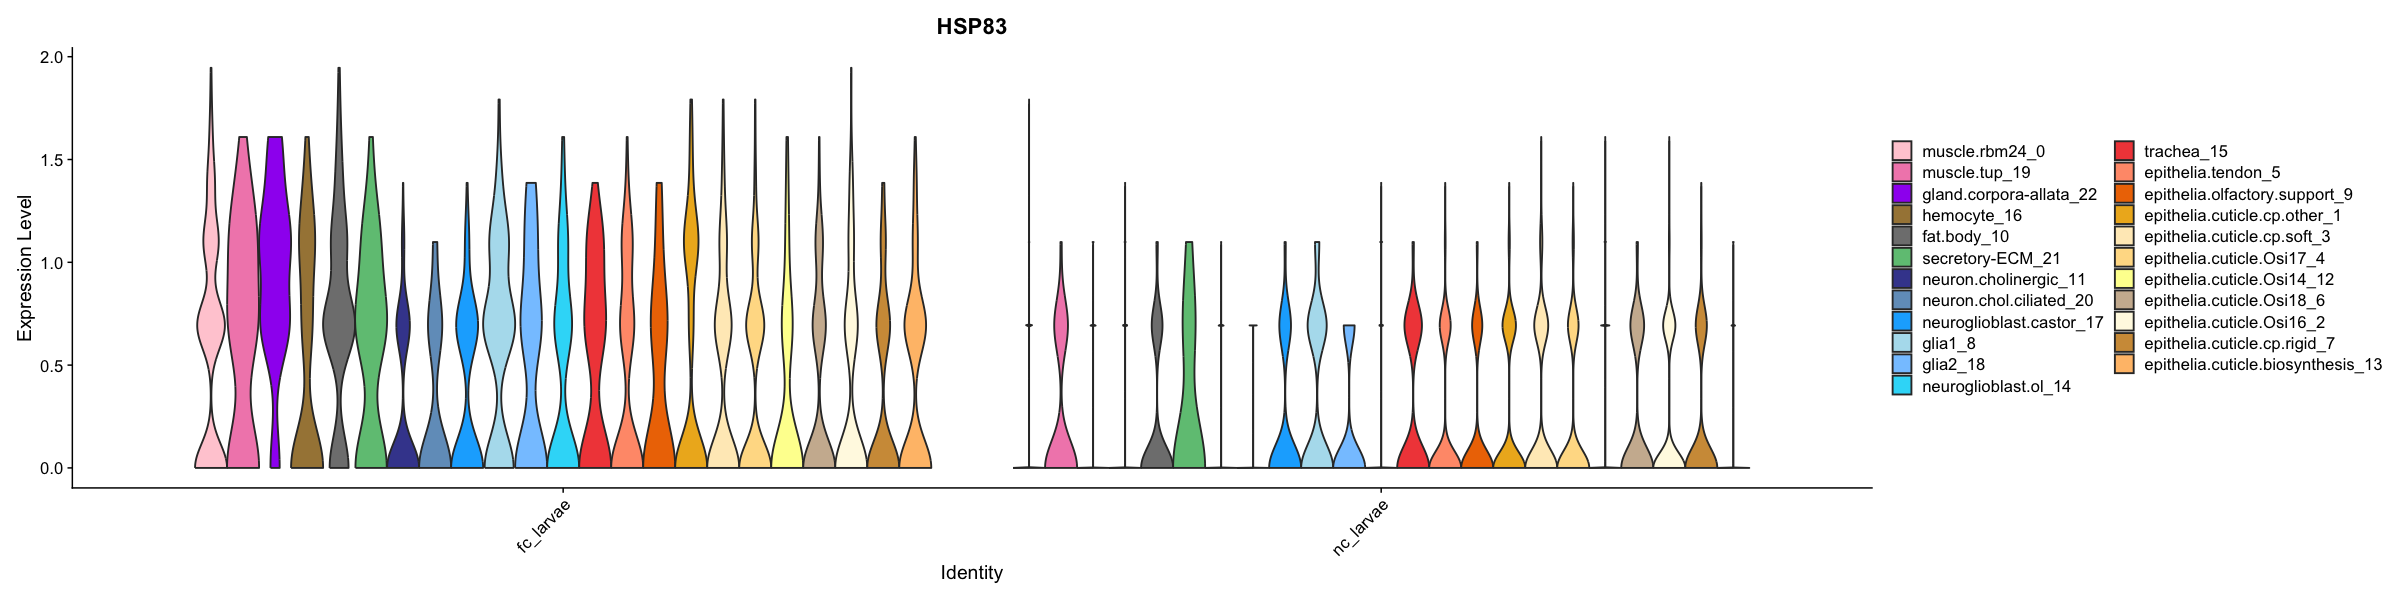

In [26]:
options(repr.plot.width = 24, repr.plot.height = 6, repr.plot.res = 100)


VlnPlot(objnames, features = c("HSP83"), alpha=0,
        split.by = "ident", group.by = "orig.ident", assay='SCT', cols=my_colors_spec[my_order])



In [27]:
all.de[all.de$gene == "HSP83", ]

,p_val,avg_log2FC,pct.1,pct.2,p_val_adj,cluster,gene
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<chr>
cluster_0.HSP83,5.983988e-158,2.1139061,0.625,0.229,6.514768e-154,0,HSP83
cluster_1.HSP83,4.038613e-16,1.3864180,0.423,0.315,4.396838e-12,1,HSP83
cluster_2.HSP83,1.435984e-06,1.0800071,0.401,0.288,1.563356e-02,2,HSP83
cluster_3.HSP83,1.957807e-06,0.8055012,0.459,0.342,2.131465e-02,3,HSP83
cluster_4.HSP83,4.934765e-14,1.1165349,0.456,0.272,5.372479e-10,4,HSP83
cluster_5.HSP83,2.306015e-09,1.2695598,0.451,0.269,2.510559e-05,5,HSP83
cluster_6.HSP83,1.148121e-03,0.7687274,0.404,0.319,1.000000e+00,6,HSP83
cluster_7.HSP83,1.486691e-04,0.9050533,0.390,0.272,1.000000e+00,7,HSP83
cluster_8.HSP83,5.284123e-11,1.0510629,0.657,0.422,5.752825e-07,8,HSP83


## 3. Gene expression heatmaps

For plots and analyses, we focus on genes that are found significantly and consistently DE using both bulk and snRMA-seq data (stored in `DEG/Consistent_DEG_UpCare.txt`). Again, these gene ids can be converted to gene names used in the manuscipt by using the gene master table `../../genome_assembly/genome_files/genes/gene_models_allinfos_for_snRNAseq.tsv`.

In [29]:
library(pheatmap)
library(tidyr)
library(tibble)

library(ComplexHeatmap)
library(circlize)
library(RColorBrewer)

Define colormap

In [30]:
my_colors <- c("#4a90e2", "#fcfcfc", "#d81b60")
full_ramp <- colorRampPalette(my_colors)(200)
col_fun = circlize::colorRamp2(seq(-3.5, 3.5, length.out = 200), full_ramp)

Focus on genes found DE using both bulk and single-nucleus RNA-seq

In [31]:
genesF <- scan("DEG/Consistent_DEG_UpCare.txt", what = character(), sep = "\n") #Up in Care
genesN <- scan("DEG/Consistent_DEG_UpNoCare.txt", what = character(), sep = "\n") #Up in NoCare

### Load bulk gene expression

In [32]:
bulk = read.table('expression_data/bulk/salmon.merged.gene_counts.tsv', sep='\t', header=T)

In [33]:
#Sample name to care condition (FC=Care, NC=NoCare)
sample_to_cond <- c(
  "F1_01"="NC", "F1_03"="NC", "F1_04"="NC", "F1_06"="NC", "F1_09A"="NC",
  "F1_14"="FC", "F1_15"="FC", "F1_16"="FC", "F1_17"="FC", "F1_18"="FC", "F1_20"="FC",
  "F2_26"="FC", "F2_27"="FC", "F2_28"="FC", "F2_31"="FC", "F2_32"="FC", "F2_34"="FC",
  "F2_36"="NC", "F2_38"="NC", "F2_41"="NC", "F2_43"="NC", "F2_45"="NC", "F2_47"="NC")

Extract bulk gene expression of DEG, separately for DEG UP in Care and DEG UP in NoCare and convert to z-scores.

In [34]:
bulk_mat <- bulk %>%
  select(-gene_id) %>%
  column_to_rownames("gene_name") %>%
  as.matrix

cpm_mat <- apply(bulk_mat, 2, function(x) (x / sum(x)) * 1e6)
log2_cpm <- log2(cpm_mat + 1)

ordered_colnames <- names(sort(sample_to_cond))
ordered_colnames <- ordered_colnames[ordered_colnames %in% colnames(log2_cpm)]
log2_cpm <- log2_cpm[, ordered_colnames]
                 
log2_cpm_N <- log2_cpm[rownames(log2_cpm) %in% genesN, ]

mat_zscore_N <- t(scale(t(log2_cpm_N)))

log2_cpm_F <- log2_cpm[rownames(log2_cpm) %in% genesF, ]

mat_zscore_F <- t(scale(t(log2_cpm_F)))

print(dim(mat_zscore_F)) #85 DEG 23 samples
print(dim(mat_zscore_N)) #172 DEG 23 samples

[1] 85 23
[1] 172  23


In [35]:
head(mat_zscore_F)

,F1_14,F1_15,F1_16,F1_17,F1_18,F1_20,F2_26,F2_27,F2_28,F2_31,⋯,F1_03,F1_04,F1_06,F1_09A,F2_36,F2_38,F2_41,F2_43,F2_45,F2_47
SGCZ,0.8163422,1.4630356,0.90688884,1.00169717,0.09510723,1.1977278,0.4298628,1.1853070,1.9671876,-0.1640700,⋯,-0.60841799,-0.38741634,-1.50063752,-1.16171636,-1.1756771,-0.1512605,-1.4695424,-1.0438237,-0.8113043,-0.9505736
ATD3A,1.2655688,1.2810427,1.20503917,1.00504467,0.47943956,0.8808431,0.1775494,0.8803429,1.2971489,0.4715989,⋯,-0.55489063,-0.36734733,-1.01653967,-1.12149419,-1.4498846,-0.7826811,-1.3467076,-1.2947404,-1.2464347,-0.7754350
5HT2A,0.2994895,1.7281393,1.31321368,0.01605982,0.43446927,0.3629304,-0.2090160,1.7173610,2.0682733,0.6718822,⋯,-0.90418563,-0.85026318,0.02768695,-1.71318213,-0.9474845,-0.1736754,-1.2306916,-0.6618952,-0.5668150,-1.0120344
LAZA-1,0.6438682,2.3886025,0.04011861,-0.11496663,-0.78428573,1.0397404,-0.3309100,1.8970999,0.8034451,-0.7092689,⋯,-0.83685414,-0.18033024,-0.94339232,-0.88189519,-0.7213143,0.8414173,-0.9433923,-0.7726240,-0.3763314,-0.9433923
CU12-6,0.2886488,1.1669321,0.61211618,0.72928029,-1.09007501,0.9726989,0.2894161,0.9926698,1.9553119,-1.4340873,⋯,0.01268775,0.04282457,-1.52211364,0.07244558,-0.1743457,0.2386457,-1.6500034,-0.7325530,-0.2447549,-1.8582522
CU12-8,1.3827895,0.5725681,-0.29523389,0.40348476,-0.89644491,-0.2934858,0.9514655,1.5307069,0.5816611,-0.9618724,⋯,-1.04673333,-0.50843238,0.13135967,0.81418949,-1.1431261,-0.2503657,-1.0837279,-0.3434370,-1.1395086,-0.9578740


### Load and prepare single-nucleus gene expression for Care UP

In [36]:
objnames$celltype.sample <- paste(objnames$seurat_clusters, objnames$orig.ident, sep = "-")

In [37]:
conditions <- c("fc_larvae", "nc_larvae")

Idents(objnames) <- objnames@meta.data$celltype.sample
current_idents <- as.character(Idents(objnames))
new_idents <- sapply(current_idents, function(x) {
  cluster_num <- sub("-.*", "", x) 
  cond_suffix <- sub(".*-", "", x)
  paste0(maplabel[cluster_num], "-", cond_suffix)
}, USE.NAMES = FALSE)

target_order <- as.vector(outer(my_order, conditions, paste, sep = "-"))
objnames$labels_clusters_conditions <- factor(new_idents, levels = target_order)
Idents(objnames) <- objnames$labels_clusters_conditions

In [38]:
p<- DotPlot(objnames, features = genesF, assay='SCT', scale=TRUE,  scale.min = 0, col.min=-4, col.max=4) + RotatedAxis() + coord_flip() +
  scale_colour_gradient2(low = "#4575b4", mid = "#f7f7f7", high = "#d73027", midpoint = 0) + theme(
    axis.text.x = element_text(size = 8), # Gene labels
    axis.text.y = element_text(size = 8), # Cluster labels
    legend.text = element_text(size = 8),  # Legend font
  )

mat_data <- p$data %>%
  select(features.plot, id, avg.exp.scaled) %>%
  pivot_wider(names_from = id, values_from = avg.exp.scaled) %>%
  column_to_rownames("features.plot") %>%
  as.matrix()

Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.


In [39]:
n_clusters_active <- rowSums(mat_data > 0.5)

groupes_genes <- ifelse(n_clusters_active <10, "spec", "share")
groupes_genes <- factor(groupes_genes, levels = c("spec", "share"))

genes_focus = c('HSP83', 'E74EA-1', 'TTKB-4', 'FTZF1', 'SAE1', 'DHX30', 'RESIL-2')

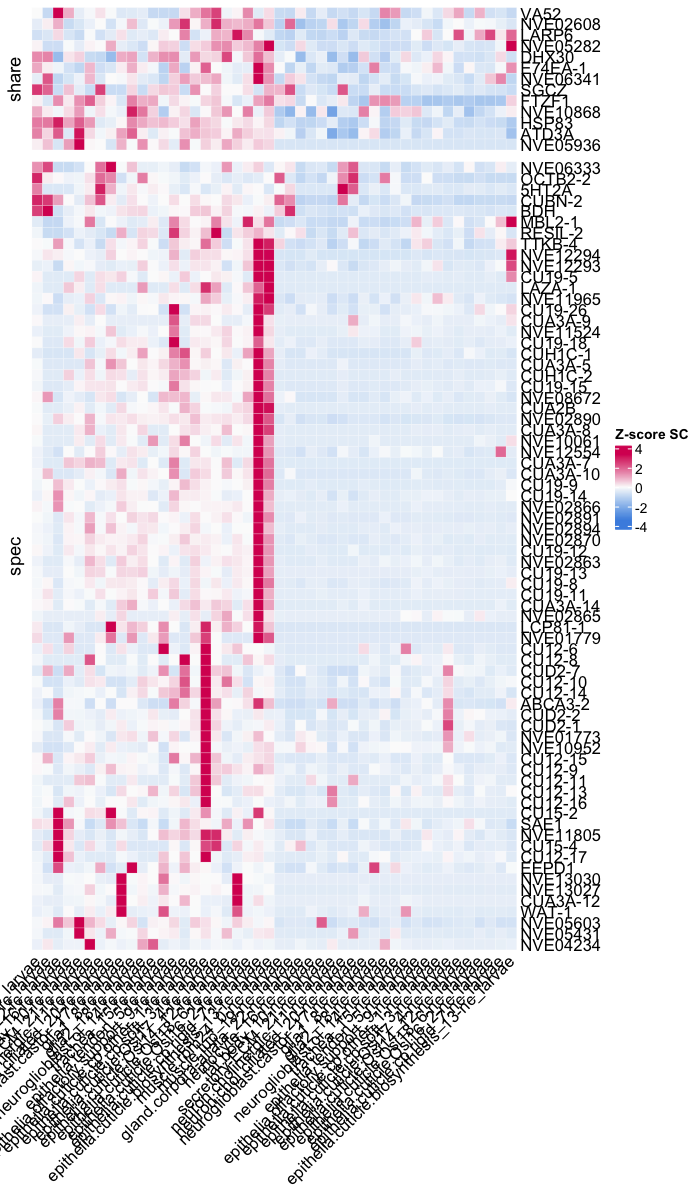

In [40]:
options(repr.plot.width = 7, repr.plot.height = 12, repr.plot.res = 100)

indices <- which(rownames(mat_data) %in% genes_focus)
labels_focus <- rownames(mat_data)[indices]

right_ann = rowAnnotation(
    link = anno_mark(at = indices, 
                     labels = labels_focus, 
                     labels_gp = gpar(fontsize = 10, fontface = "italic"))
)
    
h_sc <- Heatmap(mat_data, 
        name = "Z-score SC",
        col = col_fun,
        row_split = groupes_genes,
        # right_annotation = right_ann,
        cluster_rows = TRUE,
        cluster_columns = FALSE,
        show_row_names = T,
        show_row_dend = FALSE,
        row_gap = unit(3, "mm"),
        column_names_rot = 45,
        rect_gp = gpar(col = "white", lwd = 0.2))

h_sc = draw(h_sc)
gene_order_sc <- row_order(h_sc)

### Plot heatmaps bulk and snRNA-seq for Care UP

In [41]:
cpRR1 <- c('NVE00958','CU12-1','LCP51','CU12-2','CU12-3','CU12-4','CU12-5','CU12-6','CU12-7','CU12-8','CU12-9','CU12-10','CU12-11','NVE01773','NVE01774','NVE01775','NVE01776','CU12-12','CU15-1','NVE01779','LCP81-1','CU15-2','CU15-3','CU12-13','CU12-14','CU12-15','CU12-16','CU12-17','NVE01788','CU12-18','CU12-19','CU12-20','CU12-21','CU12-22','CU12-23','CU12-24','NVE01877','CUD8-1','CUD8-2','CUD8-3','CUD8-4','NVE01882','CUD8-5','NVE01884','CUD8-6','NVE01886','CUD2-1','CUD2-2','CUD2-3','CUD2-4','CUD2-5','CUD2-6','CUD2-7','CUD2-8','CUD2-9','CUD8-7','CUD2-10','CUD2-11','CUD2-12','CUD1','CU30-1','CU30-2','CU30-3','CU30-4','NVE01908','CUD8-8','CUD8-9','CUD8-10','CUD8-11','CUD8-12','CU17-1','CU17-2','CUD8-13','CUD4-1','CUD4-2','CUD2-13','CUD4-3','CUD4-4','CUD4-5','CUD4-6','CUD4-7','CUD4-8','CUD2-14','CUD8-14','NVE01936','CUD5','CU16-1','CU12-25','CU16-2','LCP81-2','CUD8-15','CU12-26','CUD3','CUD2-15','CUD2-16','NVE02478','NVE02742','CUD2-17','CU36-1','CU17-3','CUD8-16','CU17-4','CU17-5','CUD8-17','CUD8-18','CU12-27','NVE10281','CUD9','CU15-4','CU15-5','CUD2-18','NVE11806','CU36-2','CU36-3','CU24','NVE12293')
cpRR2 <-c('NVE01415','NVE01417','NVE01418','CU19-1','CU19-2','CU20-1','CU19-3','CU19-4','CU19-5','CU19-6','CU19-7','NVE02855','CU19-8','CU19-9','NVE02858','CU19-10','CU19-11','NVE02863','NVE02864','NVE02866','NVE02867','CU19-12','CU19-13','NVE02870','CU19-14','NVE02872','CUA3A-1','CU19-15','CU19-16','CUA3A-2','NVE02890','NVE02891','NVE02894','CU19-18','CU08','CU19-19','CU19-20','CU19-21','CU109','CU20-2','CUO8','CU19-22','CUA3A-3','CU07-1','CU19-23','NVE06852','NVE07058','NVE07059','NVE07594','RESIL-1','RESIL-2','CU198','CU07-2','CU19-24','CU22','CU19-25','CUA3A-4','CUA3A-5','CUA3A-6','CUA3A-7','CUA3A-8','CUA3A-9','CUA3A-10','CUA3A-11','CUA3A-12','CU19-26','CUA3A-14','CUO6')
chitB <- c( 'NVE00958','NVE00959','NVE00960','NVE00961','NVE00962','NVE01415','NVE01417','NVE01418','CU19-1','NVE01458','CU12-1','LCP51','CU12-2','CU12-3','CU12-4','CU12-5','CU12-6','CU12-7','CU12-8','CU12-9','CU12-10','CU12-11','NVE01773','NVE01774','NVE01775','NVE01776','CU12-12','CU15-1','NVE01779','LCP81-1','CU15-2','CU15-3','CU12-13','CU12-14','CU12-15','CU12-16','CU12-17','NVE01788','CU12-18','CU12-19','CU12-20','CU12-21','CU12-22','CU12-23','CU12-24','MBN','NVE01802','NVE01877','CUD8-1','CUD8-2','CUD8-3','CUD8-4','NVE01882','CUD8-5','NVE01884','CUD8-6','NVE01886','CUD2-1','CUD2-2','CUD2-3','CUD2-4','CUD2-5','CUD2-6','CUD2-7','CUD2-8','CUD2-9','CUD8-7','CUD2-10','CUD2-11','CUD2-12','CUD1','CU30-1','CU30-2','CU30-3','CU30-4','NVE01908','CUD8-8','CUD8-9','CUD8-10','CUD8-11','CUD8-12','CU17-1','CU17-2','CUD8-13','CUD4-1','CUD4-2','CUD2-13','CUD4-3','CUD4-4','CUD4-5','CUD4-6','CUD4-7','CUD4-8','CUD2-14','CUD8-14','NVE01936','CUD5','CU16-1','CU12-25','CU16-2','LCP81-2','CUD8-15','CU12-26','CUD3','CUD2-15','CUD2-16','NVE02263','CU19-2','NVE02478','CU20-1','CU19-3','CU19-4','NVE02742','CU19-5','CU19-6','CU19-7','NVE02855','CU19-8','CU19-9','NVE02858','CU19-10','CU19-11','NVE02863','NVE02864','NVE02866','NVE02867','CU19-12','CU19-13','NVE02870','CU19-14','NVE02872','CUA3A-1','CU19-15','CU19-16','CUA3A-2','NVE02890','NVE02891','NVE02894','CU19-18','CU08','CU19-19','CU19-20','CU19-21','CU109','CU20-2','CUO8','CU19-22','CUA3A-3','CU07-1','CU19-23','NVE06436','NVE06852','NVE07058','NVE07059','NVE07594','RESIL-1','RESIL-2','CU198','CU07-2','CUD2-17','CU36-1','CU19-24','CU22','CU17-3','CUD8-16','CU17-4','CU17-5','CUD8-17','CUD8-18','CU12-27','CU19-25','NVE10281','CUA3A-4','CUA3A-5','CUA3A-6','CUA3A-7','CUA3A-8','CUA3A-9','CUA3A-10','CUA3A-11','CUA3A-12','CUD9','CU15-4','CU15-5','CUD2-18','NVE11806','CU36-2','CU36-3','CU19-26','CU24','NVE12286','NVE12292','NVE12293','NVE12294','NVE12297','CUA3A-14','CUO6')

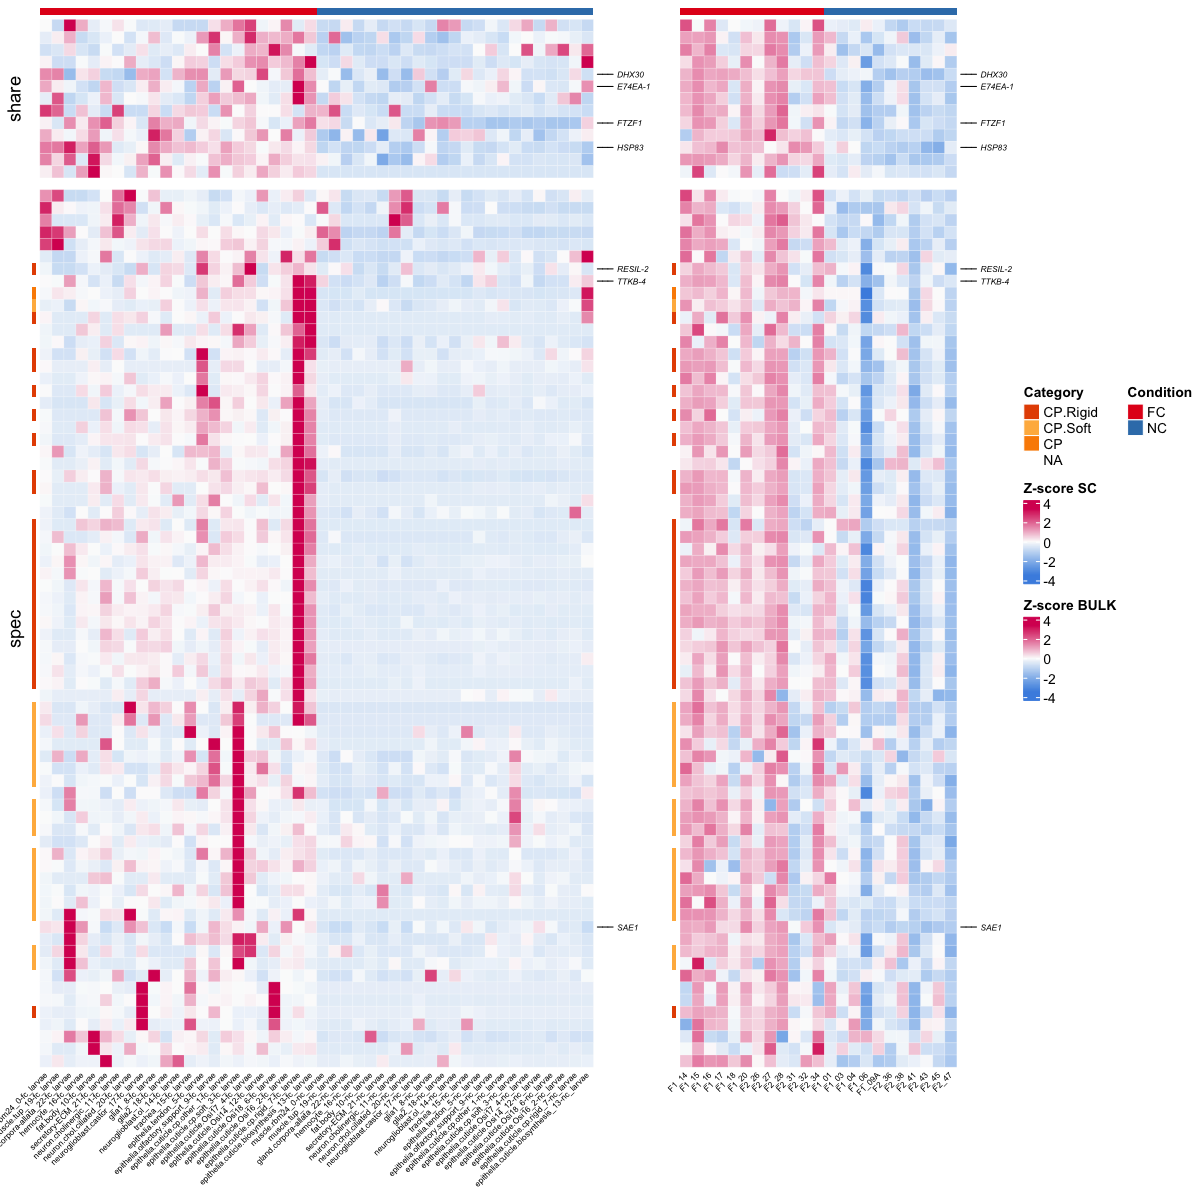

In [42]:
options(repr.plot.width = 12, repr.plot.height = 12, repr.plot.res = 100)

ordered_genes_names <- rownames(mat_data)[unlist(gene_order_sc)]
mat_zscore_F <- mat_zscore_F[ordered_genes_names, ]
groupes_genes_ordered <- factor(groupes_genes[ordered_genes_names], 
                                levels = c("share", "spec"))

indices <- which(rownames(mat_zscore_F) %in% genes_focus)
labels_focus <- rownames(mat_zscore_F)[indices]

right_ann = rowAnnotation(
    link = anno_mark(at = indices, 
                     labels = labels_focus, 
                     labels_gp = gpar(fontsize = 6, fontface = "italic"))
)

# Supposons que mat_final est votre matrice synchronisée (SC ou Bulk)
genes_all <- rownames(mat_data[ordered_genes_names, ])

# Créer un vecteur vide (ou "Other")
cat_genes <- rep("NA", length(genes_all))
names(cat_genes) <- genes_all

# Assigner les catégories basées sur vos vecteurs
cat_genes[names(cat_genes) %in% chitB] <- "CP"

cat_genes[names(cat_genes) %in% cpRR2] <- "CP.Rigid"
cat_genes[names(cat_genes) %in% cpRR1]  <- "CP.Soft"

# Convertir en facteur pour fixer les couleurs
cat_genes <- factor(cat_genes, levels = c("CP.Rigid", "CP.Soft", "CP", "NA"))

col_cat = c("CP.Rigid" = "#E65100", "CP.Soft" = "#FFB74D", "CP" = "#FB8C00", "NA" = "white")

left_ann = rowAnnotation(
    Category = cat_genes,
    col = list(Category = col_cat),
    show_annotation_name = FALSE,
        simple_anno_size = unit(0.1, "cm")

)

col_samp <- c("FC" = "#E41A1C", "NC" = "#377EB8")
sample_names <- colnames(mat_data)
group_vec <- ifelse(grepl("fc_l", sample_names), "FC", "NC")
names(group_vec) <- sample_names

column_ha_sc <- HeatmapAnnotation(
  Condition = group_vec,
  col = list(Condition = col_samp),
    show_annotation_name = F,
  simple_anno_size = unit(0.2, "cm") 
)


sample_to_cond <- sample_to_cond[ordered_colnames]
column_ha <- HeatmapAnnotation(
  Condition = sample_to_cond,
  col = list(Condition = col_samp),
  show_annotation_name = F,
      simple_anno_size = unit(0.2, "cm")

)
    
h_sc <- Heatmap(mat_data[ordered_genes_names, ], 
        name = "Z-score SC",
        col = col_fun,
        row_split = groupes_genes_ordered,     
        cluster_row_slices = FALSE,   
        cluster_rows = FALSE,
        right_annotation = right_ann,
                left_annotation = left_ann,
                top_annotation = column_ha_sc,
        cluster_columns = FALSE,        
        show_row_names = F,
        row_gap = unit(3, "mm"),
        column_names_rot = 45,
                        column_names_gp = gpar(fontsize = 6),

        rect_gp = gpar(col = "white", lwd = 0.2)
)

h_bulk <- Heatmap(mat_zscore_F, 
        name = "Z-score BULK",
        col = col_fun,
        row_split = groupes_genes_ordered,     
        cluster_row_slices = FALSE,   
        cluster_rows = FALSE,
        right_annotation = right_ann,
                  top_annotation = column_ha,
                  left_annotation = left_ann,
        cluster_columns = FALSE,
        column_order = ordered_colnames,
        
        show_row_names = F,
        row_gap = unit(3, "mm"),
        column_names_rot = 45,
                          column_names_gp = gpar(fontsize = 6),

        rect_gp = gpar(col = "white", lwd = 0.2)
)

combined_h = h_sc + h_bulk
# cairo_pdf(file = "DEG_Care.pdf", width = 9, height = 8) # defaults to 7 x 7 inches

draw(combined_h, 
     ht_gap = unit(5, "mm"),
     main_heatmap = "Z-score SC",     
     annotation_legend_side = "right")
# dev.off()

### Load and prepare single-nucleus gene expression for NoCare UP

In [43]:
options(repr.plot.width = 10, repr.plot.height = 12, repr.plot.res = 100)

p<- DotPlot(objnames, features = genesN, assay='SCT', scale=TRUE,  scale.min = 0, col.min=-4, col.max=4) + RotatedAxis() + coord_flip() +
  scale_colour_gradient2(low = "#4575b4", mid = "#f7f7f7", high = "#d73027", midpoint = 0) + theme(
    axis.text.x = element_text(size = 8), # Gene labels
    axis.text.y = element_text(size = 8), # Cluster labels
    legend.text = element_text(size = 8),  # Legend font
  )

mat_data <- p$data %>%
  select(features.plot, id, avg.exp.scaled) %>%
  pivot_wider(names_from = id, values_from = avg.exp.scaled) %>%
  column_to_rownames("features.plot") %>%
  as.matrix()

Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.


In [44]:
n_clusters_active <- rowSums(mat_data > 0.5)

groupes_genes <- ifelse(n_clusters_active <10, "spec", "share")
groupes_genes <- factor(groupes_genes, levels = c("share", "spec"))

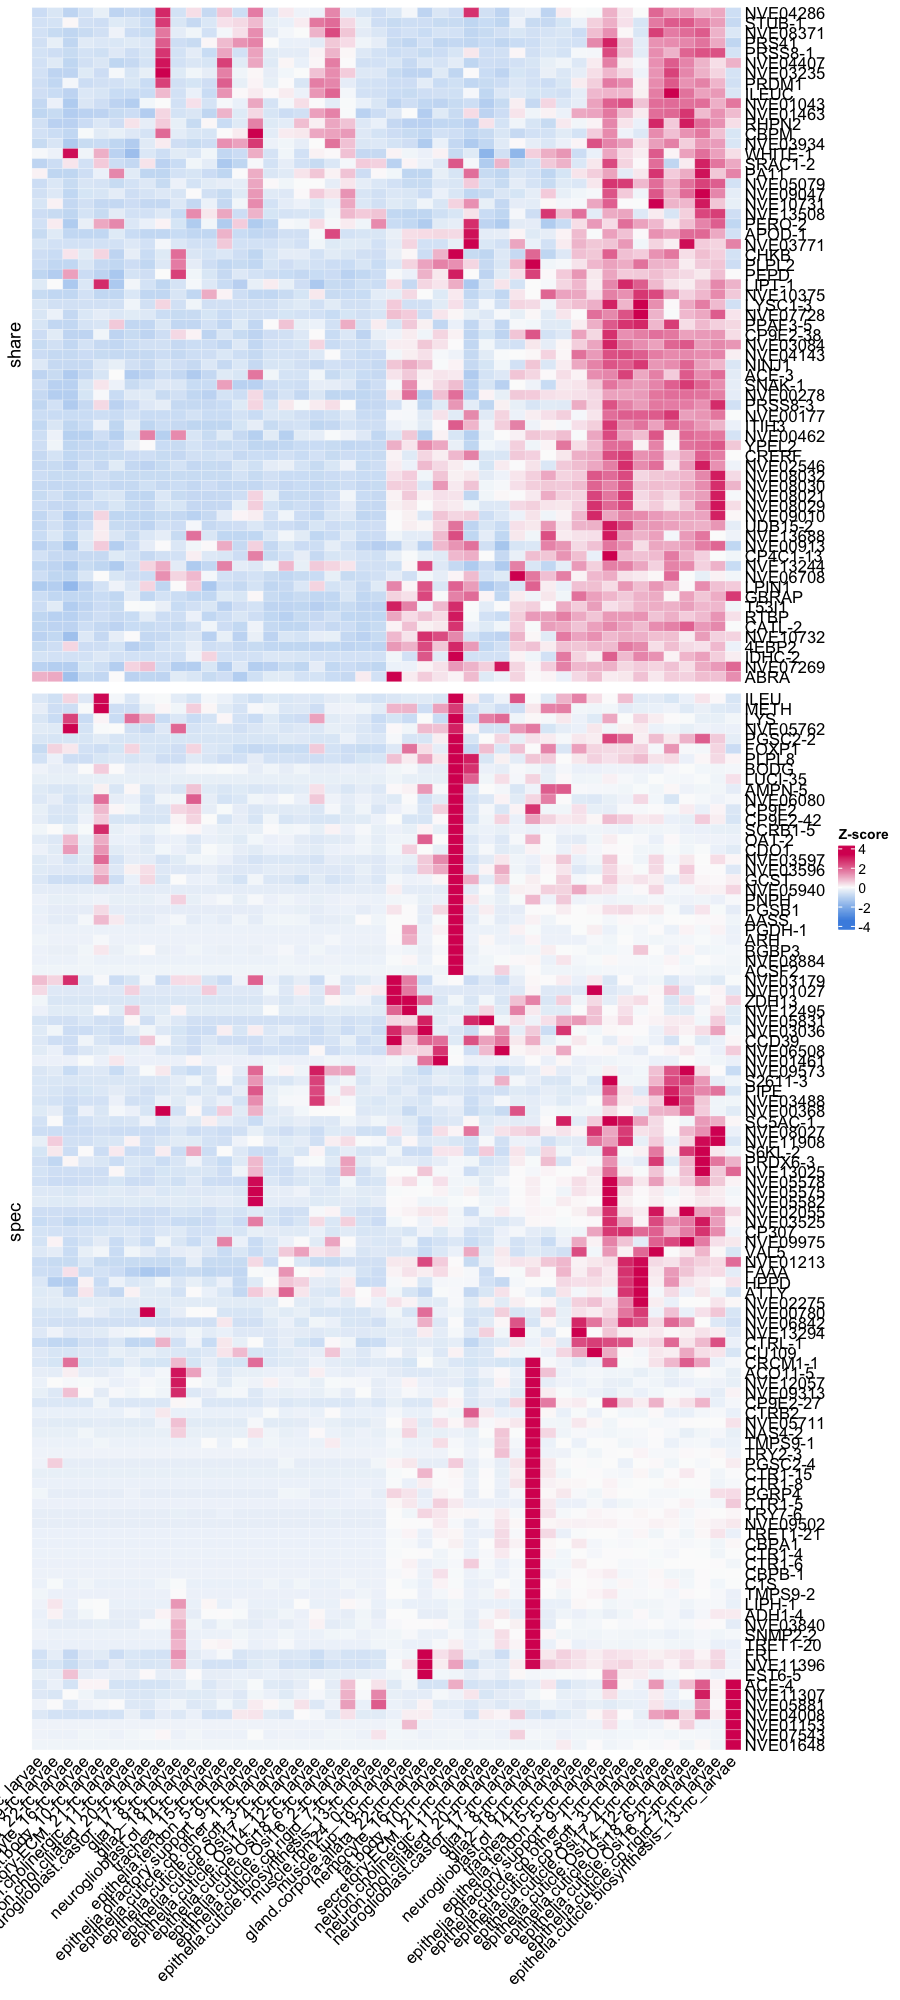

In [45]:
options(repr.plot.width = 9, repr.plot.height = 20, repr.plot.res = 100)

h_sc <- Heatmap(mat_data, 
        name = "Z-score",
        col = col_fun,
        row_split = groupes_genes,
        cluster_rows = TRUE,
        cluster_columns = FALSE,
        show_row_names = T,
                # right_annotation = row_anno,
        show_row_dend = FALSE,
        row_gap = unit(3, "mm"),
        column_names_rot = 45,
        rect_gp = gpar(col = "white", lwd = 0.2))

h_sc = draw(h_sc)
gene_order_sc <- row_order(h_sc)

In [46]:
groupes_genes_ordered <- factor(groupes_genes[ordered_genes_names], 
                                 levels = c("share", "spec"))

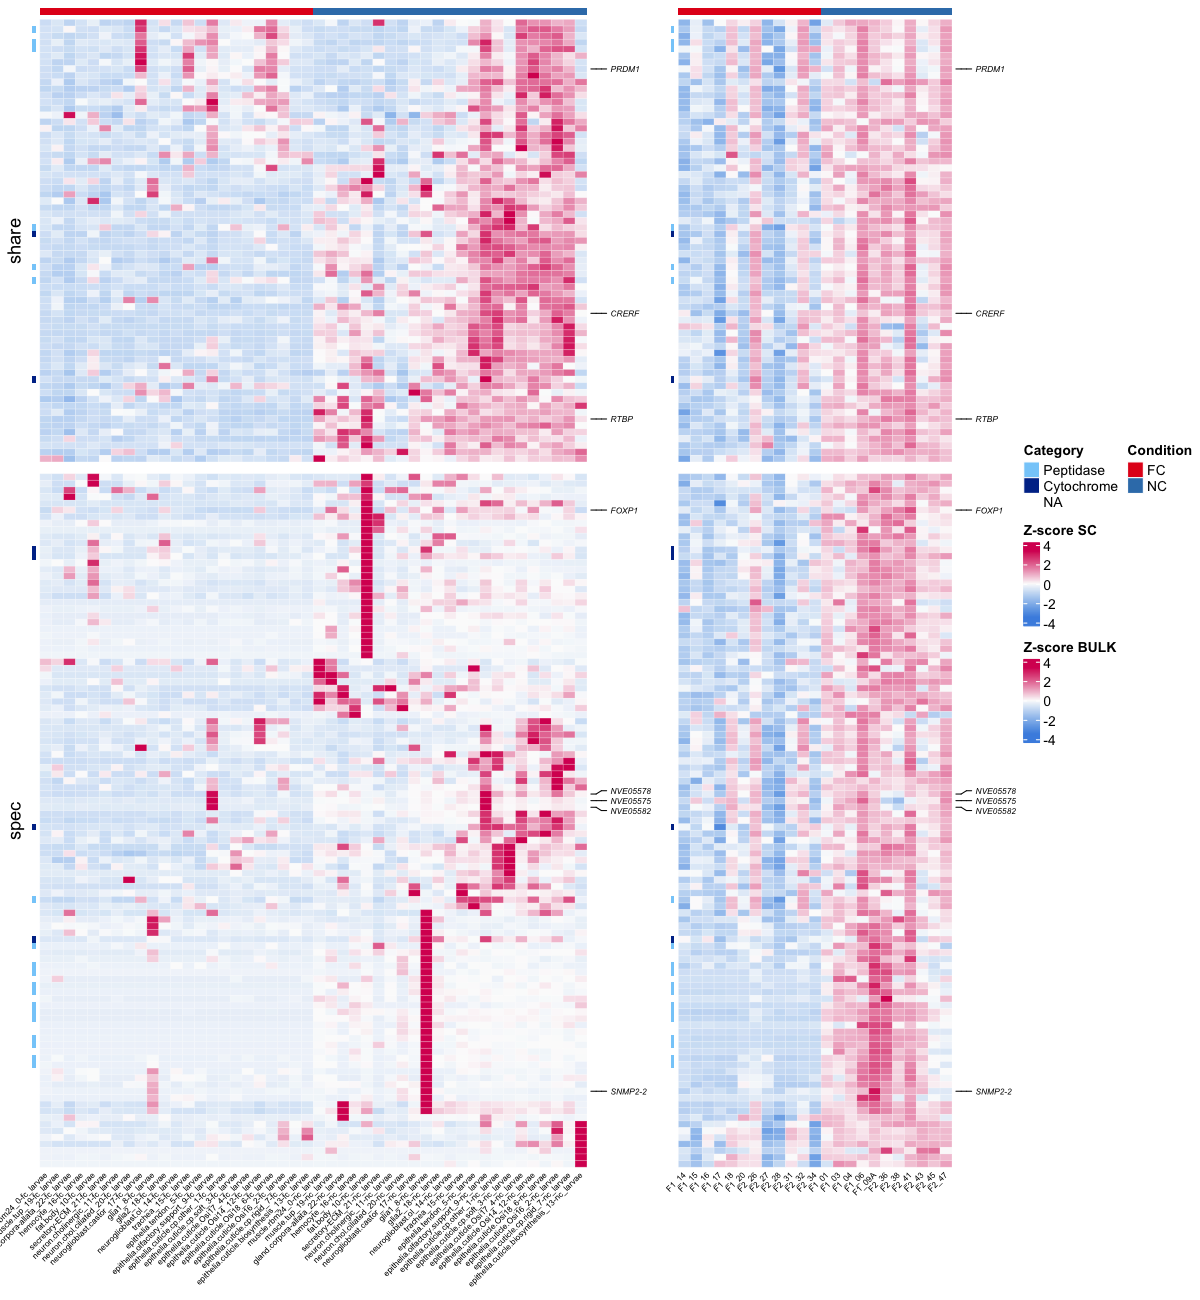

In [47]:
options(repr.plot.width = 12, repr.plot.height = 13, repr.plot.res = 100)

TFs_plus_odb = c('PRDM1', 'CRERF', 'RTBP', 'FOXP1', 'SNMP2-2', 'NVE05575', 'NVE05578', 'NVE05582')

trypsin <- c(
  "SNAK-1", "CTRL-1", "PRSS8-1", "TMPS9-1", "PRS41", 
  "STUB-1", "CTRB2", "CTR1-4", "CTR1-5", "CTR1-6", 
  "CTR1-8", "CTR1-15", "NVE09502", "TMPS9-2", "TRY7-6", 
  "TRY2-3", "C1S", "PPAF3-5", "PRSS8-3"
)

cytoC <- c(
   "CP307", "CP9E2-27", "CP9E2-38", "CP9F2", "CP9E2-42", "CP4C1-13"
 )

genes_focus <- c(TFs_plus_odb)

ordered_genes_names <- rownames(mat_data)[unlist(gene_order_sc)]

groupes_genes_ordered <- factor(groupes_genes[ordered_genes_names], 
                                levels = c("share", "spec"))
mat_zscore_N <- mat_zscore_N[ordered_genes_names, ]
indices <- which(rownames(mat_zscore_N) %in% genes_focus)
labels_focus <- rownames(mat_zscore_N)[indices]

right_ann = rowAnnotation(
    link = anno_mark(at = indices, 
                     labels = labels_focus, 
                     labels_gp = gpar(fontsize = 6, fontface = "italic"))
)

# Supposons que mat_final est votre matrice synchronisée (SC ou Bulk)
genes_all <- rownames(mat_data[ordered_genes_names, ])

# # Créer un vecteur vide (ou "Other")
cat_genes <- rep("NA", length(genes_all))
names(cat_genes) <- genes_all

# # Assigner les catégories basées sur vos vecteurs
cat_genes[names(cat_genes) %in% trypsin] <- "Peptidase"

cat_genes[names(cat_genes) %in% cytoC] <- "Cytochrome"
# cat_genes[names(cat_genes) %in% cpRR1]  <- "CP.Soft"

# # Convertir en facteur pour fixer les couleurs
cat_genes <- factor(cat_genes, levels = c("Peptidase","Cytochrome", "NA"))

col_cat = c("Peptidase" = "#86CEFA", "Cytochrome"= '#003396', "NA" = "white")

left_ann = rowAnnotation(
    Category = cat_genes,
    col = list(Category = col_cat),
    show_annotation_name = FALSE,
    simple_anno_size = unit(0.1, "cm")
)

col_samp <- c("FC" = "#E41A1C", "NC" = "#377EB8")
sample_names <- colnames(mat_data)
group_vec <- ifelse(grepl("fc_l", sample_names), "FC", "NC")
names(group_vec) <- sample_names

column_ha_sc <- HeatmapAnnotation(
  Condition = group_vec,
  col = list(Condition = col_samp),
  simple_anno_size = unit(0.2, "cm"),
  show_annotation_name = F
)


sample_to_cond <- sample_to_cond[ordered_colnames]
column_ha <- HeatmapAnnotation(
  Condition = sample_to_cond,
  col = list(Condition = col_samp),
   simple_anno_size = unit(0.2, "cm"),
  show_annotation_name = F
)

h_sc <- Heatmap(mat_data[ordered_genes_names, ], 
        name = "Z-score SC",
        col = col_fun,
        row_split = groupes_genes_ordered,     
        cluster_row_slices = FALSE,   
        cluster_rows = FALSE,
        right_annotation = right_ann,
                left_annotation = left_ann,
                top_annotation = column_ha_sc,
        cluster_columns = FALSE,        
        show_row_names = F,
                column_names_gp = gpar(fontsize = 6),
        row_gap = unit(3, "mm"),
        column_names_rot = 45,
        rect_gp = gpar(col = "white", lwd = 0.2)
)

h_bulk <- Heatmap(mat_zscore_N, 
        name = "Z-score BULK",
        col = col_fun,
        row_split = groupes_genes_ordered,     
        cluster_row_slices = FALSE,   
        cluster_rows = FALSE,
        right_annotation = right_ann,
                  left_annotation = left_ann,
                  top_annotation = column_ha,
        cluster_columns = FALSE,
        column_order = ordered_colnames,
        column_names_gp = gpar(fontsize = 6),
        show_row_names = F,
        row_gap = unit(3, "mm"),
        column_names_rot = 45,
        rect_gp = gpar(col = "white", lwd = 0.2)
)

combined_h = h_sc + h_bulk

#cairo_pdf(file = "DEG_NOCare.pdf", width = 9, height = 13) # defaults to 7 x 7 inches

draw(combined_h, 
     ht_gap = unit(5, "mm"),        # Espace entre les deux heatmaps
     main_heatmap = "Z-score SC",     
     annotation_legend_side = "right")
#dev.off()